<a href="https://colab.research.google.com/github/harshil-hue/DataStructuresandAlgorithms/blob/main/MachineLearning(Binning_%26_Binarization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("diabetes.csv" , usecols=['Age' , 'BMI' , 'BloodPressure' , 'Glucose' , 'Outcome'])

In [ ]:
df.sample(7)

,Glucose,BloodPressure,BMI,Age,Outcome
61,133,72,32.9,39,1
162,114,80,44.2,27,0
663,145,80,37.9,40,1
7,115,0,35.3,29,0
556,97,70,38.1,30,0
586,143,66,34.9,41,1
659,80,82,34.2,27,1


<Axes: xlabel='Glucose', ylabel='Count'>

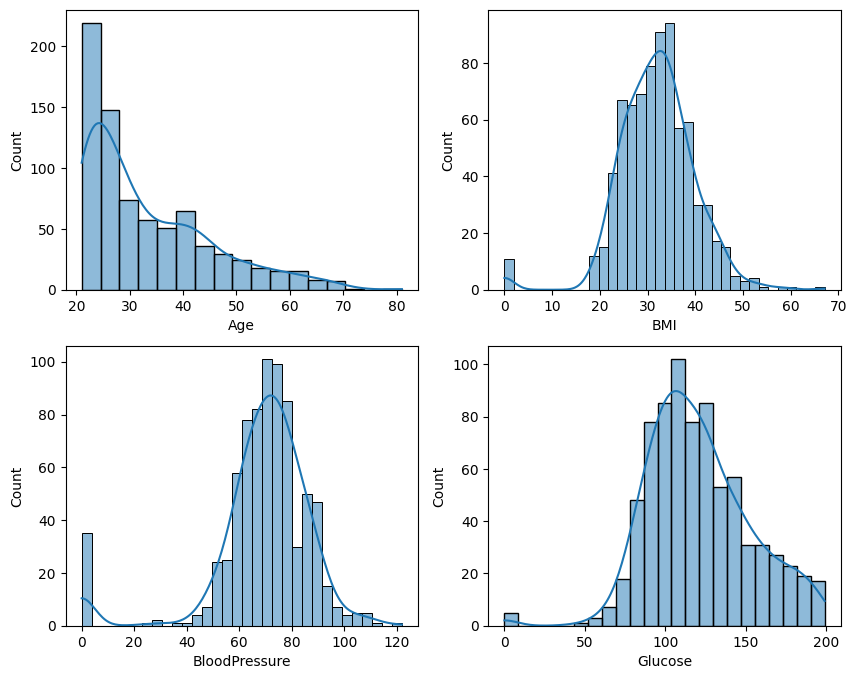

In [ ]:
fig , axes = plt.subplots(2 , 2 , figsize = (10,8))
sns.histplot(df['Age'],kde = True , ax=axes[0, 0])
sns.histplot(df['BMI'],kde = True , ax=axes[0, 1])
sns.histplot(df['BloodPressure'],kde = True , ax=axes[1, 0])
sns.histplot(df['Glucose'],kde = True , ax=axes[1, 1])

In [ ]:
df.describe()

,Glucose,BloodPressure,BMI,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,31.992578,33.240885,0.348958
std,31.972618,19.355807,7.884160,11.760232,0.476951
min,0.000000,0.000000,0.000000,21.000000,0.000000
25%,99.000000,62.000000,27.300000,24.000000,0.000000
50%,117.000000,72.000000,32.000000,29.000000,0.000000
75%,140.250000,80.000000,36.600000,41.000000,1.000000
max,199.000000,122.000000,67.100000,81.000000,1.000000


In [ ]:
df.shape

(768, 5)

# Binning / Discretization

In [ ]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

### Without Using Binning / Discretization

In [ ]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state=42)

In [ ]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred = dtc.predict(X_test)
accuracy_score(y_test , y_pred)

0.7077922077922078

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier() , X , y , cv = 10 , scoring = "accuracy"))

np.float64(0.6914900888585099)

### Using Binning / Discretization

In [ ]:
kbin = KBinsDiscretizer(n_bins=21 , encode='ordinal' , strategy = 'quantile')

In [ ]:
trf = ColumnTransformer([
    ('first' , kbin , ['Age'] ),
    ('second' , kbin , ['BMI'] ),
    ('third' , kbin , ['BloodPressure'] ),
    ('forth' , kbin , ['Glucose'] ),
])

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [ ]:
dtc.fit(X_train_trf , y_train)
y_pred_trf = dtc.predict(X_test_trf)
accuracy_score(y_test , y_pred_trf)

0.6948051948051948

In [ ]:
X_trf = trf.fit_transform(X)
X_trf_dataframe = pd.DataFrame(X_trf , columns = X.columns)
X_trf_dataframe

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


,Glucose,BloodPressure,BMI,Age
0,15.0,12.0,10.0,17.0
1,9.0,4.0,7.0,2.0
2,9.0,1.0,6.0,20.0
3,0.0,6.0,7.0,2.0
4,9.0,19.0,1.0,15.0
...,...,...,...,...
763,17.0,11.0,13.0,6.0
764,6.0,16.0,9.0,11.0
765,8.0,4.0,10.0,11.0
766,15.0,8.0,4.0,13.0


In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier() , X_trf , y , cv = 10 ,scoring = "accuracy"))

np.float64(0.6691216678058785)

<Axes: xlabel='Glucose', ylabel='Count'>

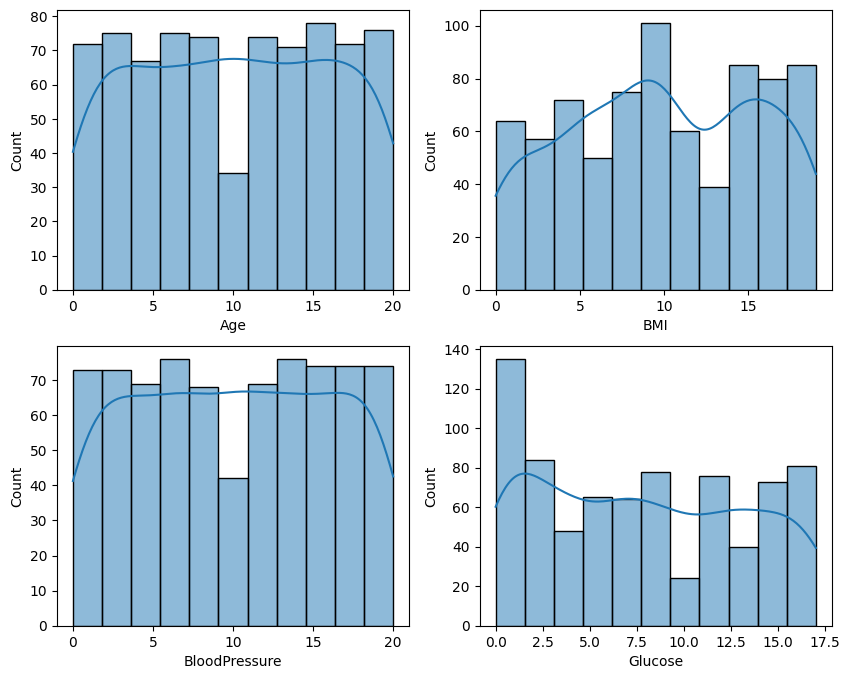

In [ ]:
fig , axes = plt.subplots(2,2,figsize = (10,8))

sns.histplot(X_trf_dataframe['Age'] , kde = True , ax = axes[0,0])
sns.histplot(X_trf_dataframe['BMI'] , kde = True , ax = axes[0,1])
sns.histplot(X_trf_dataframe['BloodPressure'] , kde = True , ax = axes[1,0])
sns.histplot(X_trf_dataframe['Glucose'] , kde = True , ax = axes[1,1])

### Binning Function

In [ ]:
def Discretization(bins , strategy):
    kbin = KBinsDiscretizer(n_bins = bins , strategy = strategy , encode = "ordinal")
    trf = ColumnTransformer([
        ('first' , kbin , ['Age']),
        ('second' , kbin , ['BMI']),
        ('third' , kbin , ['BloodPressure']),
        ('forth' , kbin , ['Glucose']),
    ])

    X_train_trf = trf.fit_transform(X_train)
    X_test_trf = trf.transform(X_test)

    X_train_trf_df = pd.DataFrame(X_train_trf , columns = X_train.columns)


    fig , axes = plt.subplots(4,2,figsize = (10,20))
    sns.histplot(X_train['Age'] , kde = True , ax=axes[0,0])
    sns.histplot(X_train_trf_df['Age'] , kde = True , ax=axes[0,1])
    sns.histplot(X_train['BMI'] , kde = True , ax=axes[1,0])
    sns.histplot(X_train_trf_df['BMI'] , kde = True , ax=axes[1,1])
    sns.histplot(X_train['BloodPressure'] , kde = True , ax=axes[2,0])
    sns.histplot(X_train_trf_df['BloodPressure'] , kde = True , ax=axes[2,1])
    sns.histplot(X_train['Glucose'] , kde = True , ax=axes[3,0])
    sns.histplot(X_train_trf_df['Glucose'] , kde = True , ax=axes[3,1])


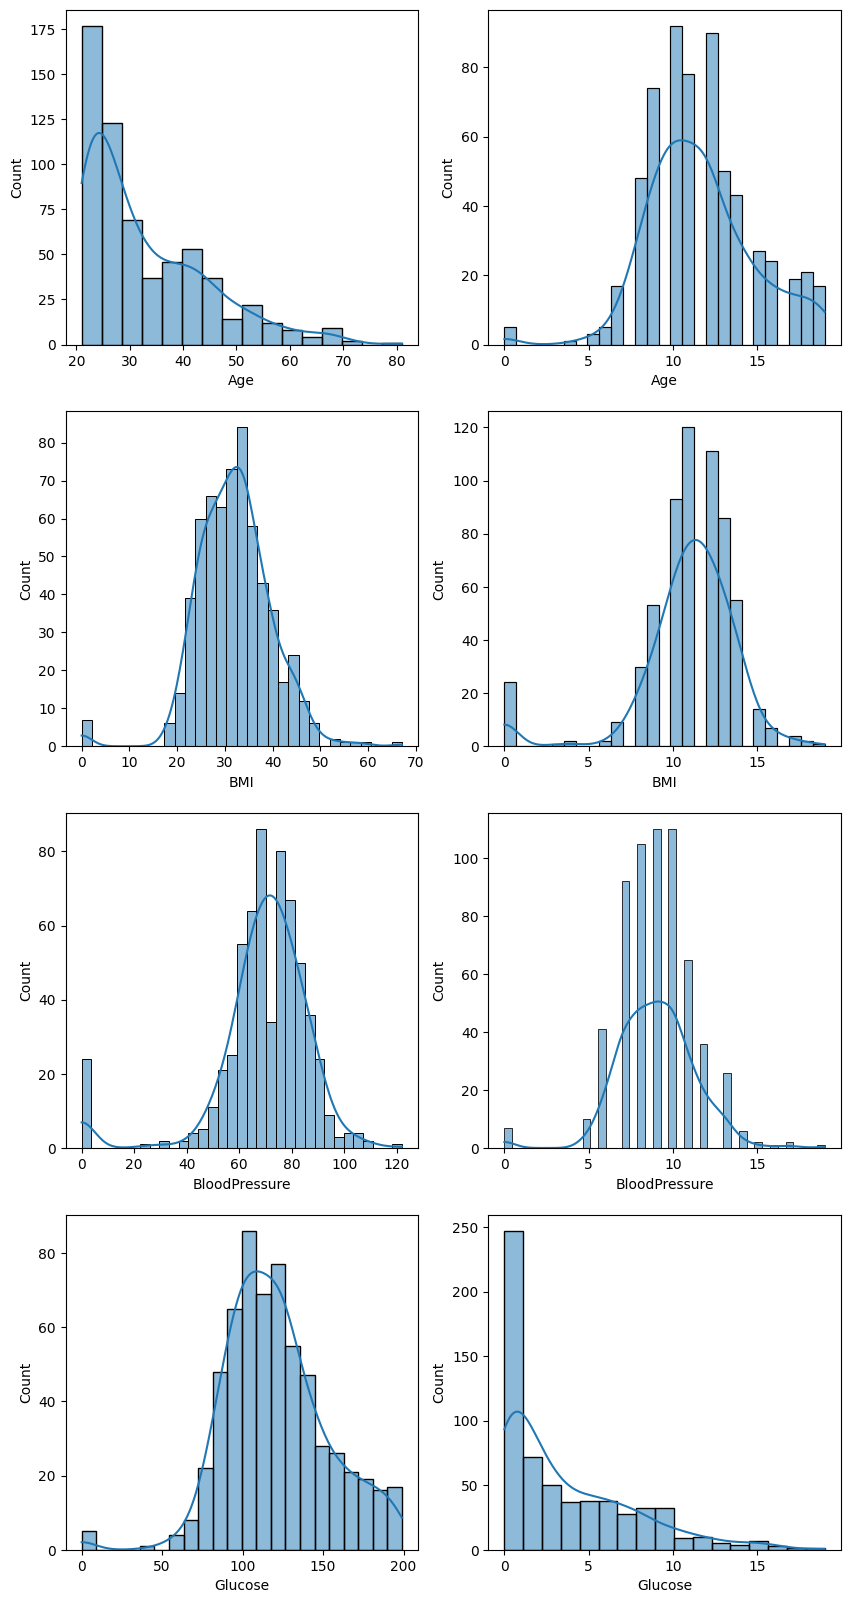

In [ ]:
Discretization(20,"uniform")

# Binarization

In [ ]:
from sklearn.preprocessing import Binarizer

In [ ]:
trf = ColumnTransformer([
    ('bin' , Binarizer(threshold=24.9 , copy = False) , ['BMI'])
] , remainder = 'passthrough')

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
X_train_trf_df = pd.DataFrame(X_train_trf ,columns =  trf.get_feature_names_out())
X_train_trf_df.sample(20)

,bin__BMI,remainder__Glucose,remainder__BloodPressure,remainder__Age
3,0.0,161.0,50.0,65.0
181,1.0,108.0,62.0,21.0
471,1.0,163.0,72.0,47.0
215,1.0,146.0,56.0,29.0
192,1.0,81.0,86.0,22.0
286,1.0,125.0,78.0,49.0
88,1.0,133.0,72.0,39.0
175,0.0,0.0,48.0,22.0
300,1.0,65.0,72.0,42.0
20,1.0,155.0,84.0,34.0
